In [ ]:
# base
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    explained_variance_score,
)

# models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
import joblib

In [12]:
warnings.filterwarnings('ignore')

df = pd.read_parquet("~/code/drone/eda/data/flight.parquet", engine="pyarrow")
df

,flight,payload,route,altitude_preset,date,time_day,duration_s,total_distance_m,wind_speed_mean,wind_speed_std,...,velocity_mag_max,acceleration_mag_mean,acceleration_mag_std,battery_voltage_mean,battery_voltage_min,max_height_agl,final_height_agl,energy_consumed_Wh,battery_needed_mAh,landing_offset_flag
0,1,0.0,R5,25,2019-04-07,10:13,200.70,549.065984,3.898058,1.952675,...,6.261616,9.842870,0.466372,22.070134,21.228519,26.257755,-0.994409,21.769975,1000.743935,False
1,2,0.0,R5,50,2019-04-07,10:23,271.20,666.615556,3.522941,2.159456,...,7.676739,9.881874,0.628406,21.527547,20.125463,52.637988,0.589477,25.366627,1205.255874,False
2,3,0.0,R5,25,2019-04-07,10:33,180.10,577.009957,4.581182,3.335733,...,7.213987,9.902090,0.545290,22.330305,19.943916,24.660462,0.106140,17.094392,789.073853,False
3,4,0.0,R5,25,2019-04-07,10:48,171.00,562.802357,4.596319,3.438072,...,9.425537,9.900368,0.559073,21.950616,20.365856,25.580572,0.416669,14.690038,687.813976,False
4,5,0.0,R2,25,2019-04-07,11:05,217.00,470.978276,3.333910,2.247522,...,4.900079,9.817243,0.341981,21.519937,18.923494,24.323036,-0.924901,19.019928,920.070980,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,275,500.0,R1,25,2019-10-24,9:05,149.40,518.231162,4.139878,3.885389,...,8.788151,9.850903,0.420902,22.056616,20.332052,21.959932,-3.264891,16.295811,760.480643,False
205,276,500.0,R1,25,2019-10-24,9:32,147.90,517.758034,4.392581,4.332293,...,10.553163,9.862172,0.471081,21.492353,19.788662,22.542598,1.293232,15.392088,738.620356,False
206,277,500.0,R1,25,2019-10-24,9:45,134.81,517.677109,5.524651,4.029744,...,10.579715,9.847796,0.529103,21.908016,19.352947,24.289124,-0.286362,15.531389,741.451254,False
207,278,500.0,R7,25-50-100-25,2019-10-24,10:00,186.39,545.413261,4.686967,3.826570,...,10.376503,9.829065,0.456918,22.394109,20.407175,95.041887,-0.457578,18.922540,887.198699,False


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   flight                 209 non-null    int64   
 1   payload                209 non-null    float64 
 2   route                  209 non-null    category
 3   altitude_preset        209 non-null    string  
 4   date                   209 non-null    str     
 5   time_day               209 non-null    str     
 6   duration_s             209 non-null    float64 
 7   total_distance_m       209 non-null    float64 
 8   wind_speed_mean        209 non-null    float64 
 9   wind_speed_std         209 non-null    float64 
 10  wind_x_mean            209 non-null    float64 
 11  wind_y_mean            209 non-null    float64 
 12  speed_mean             209 non-null    float64 
 13  speed_max              209 non-null    float64 
 14  velocity_mag_mean      209 non-null    float64 
 15  

In [14]:
selection_cols = [
    'total_distance_m',
    'max_height_agl',
    'payload',
    'wind_speed_mean',
    'velocity_mag_mean',
    'speed_max',
    'speed_mean',
    'acceleration_mag_mean'
]
target = 'duration_s'

In [15]:
X = df[selection_cols]
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state= 42)

sc = StandardScaler()

x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [16]:
x_train_sc.shape, y_train.shape, x_test_sc.shape, y_test.shape

((167, 8), (167,), (42, 8), (42,))

In [17]:
lr_model = Ridge(
    alpha=0.07519487100334402,
    random_state=42,
)
ada_model = AdaBoostRegressor(
    n_estimators=393,
    learning_rate=0.4522723702483474,
    loss="square",
    random_state=42,
)

rf_model = RandomForestRegressor(
    n_estimators=412,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features=None,
    n_jobs=-1,
    random_state=42,
)

xgb_model = XGBRegressor(
    max_depth=3,
    learning_rate=0.13134475757064812,
    subsample=0.838706297390557,
    colsample_bytree=0.9009396859862594,
    reg_alpha=0.0031231223121617247,
    reg_lambda=0.032877834020447624,
    min_child_weight=3,
    n_estimators=216,
    n_jobs=-1,
    random_state=42,
)

lgbm_model = LGBMRegressor(
    num_leaves=37,
    max_depth=4,
    learning_rate=0.06917366736408287,
    feature_fraction=0.8008892283061073,
    bagging_fraction=0.5365330336088984,
    min_child_samples=6,
    n_estimators=147,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)

lr_model.fit(x_train_sc, y_train)
ada_model.fit(x_train_sc, y_train)
rf_model.fit(x_train_sc, y_train)
xgb_model.fit(x_train_sc, y_train)
lgbm_model.fit(x_train_sc, y_train)

,num_leaves,37
,max_depth,4
,learning_rate,0.06917366736408287
,n_estimators,147
,min_child_samples,6
,random_state,42
,n_jobs,-1
,feature_fraction,0.8008892283061073
,bagging_fraction,0.5365330336088984
,verbose,-1
,boosting_type,'gbdt'


In [18]:
models = {
    'Linear Regression': lr_model,
    'Ada Boost': ada_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model,
}

y_test= np.array(y_test)
pred_table = pd.DataFrame(y_test, columns=['true_val'])
for name, model in models.items():
    print()
    print(name)
    y_pred = model.predict(x_test_sc)
    pred_table[name] = y_pred
    metrics = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "MedianAE": median_absolute_error(y_test, y_pred),
        "ExplainedVariance": explained_variance_score(y_test, y_pred),
    }

    for k, v in metrics.items():
        print(f"{k:<20}: {v:.6f}")
        


Linear Regression
MAE                 : 6.810643
MSE                 : 100.026522
RMSE                : 10.001326
R2                  : 0.931305
MAPE                : 0.039567
MedianAE            : 5.274669
ExplainedVariance   : 0.936744

Ada Boost
MAE                 : 12.559591
MSE                 : 285.102248
RMSE                : 16.884971
R2                  : 0.804202
MAPE                : 0.078779
MedianAE            : 8.829992
ExplainedVariance   : 0.844092

Random Forest
MAE                 : 6.289325
MSE                 : 83.705300
RMSE                : 9.149060
R2                  : 0.942514
MAPE                : 0.038180
MedianAE            : 3.982886
ExplainedVariance   : 0.944881

XGBoost
MAE                 : 5.856560
MSE                 : 171.183050
RMSE                : 13.083694
R2                  : 0.882438
MAPE                : 0.034734
MedianAE            : 2.522380
ExplainedVariance   : 0.882639

LightGBM
MAE                 : 4.907141
MSE                 : 48.6

In [20]:
pred_table

,true_val,Linear Regression,Ada Boost,Random Forest,XGBoost,LightGBM
0,182.69,188.899367,186.811875,181.202361,183.639969,181.774222
1,141.40,135.853222,143.593333,138.924074,142.086670,136.970615
2,182.50,182.672906,175.249500,184.153326,175.897644,173.261074
3,152.61,154.556274,152.688980,153.844414,151.345078,149.675052
4,138.40,132.090270,144.862500,136.524470,139.947983,135.709653
5,142.80,123.956992,135.357143,116.529106,67.897003,131.616939
6,221.10,221.703044,209.823611,214.910950,221.420853,218.850126
7,187.60,188.516708,194.190952,191.535622,193.517868,188.843831
8,116.21,92.769680,144.133947,130.548326,118.759804,121.205231
9,172.51,172.124408,182.505714,174.595224,174.988876,175.385513


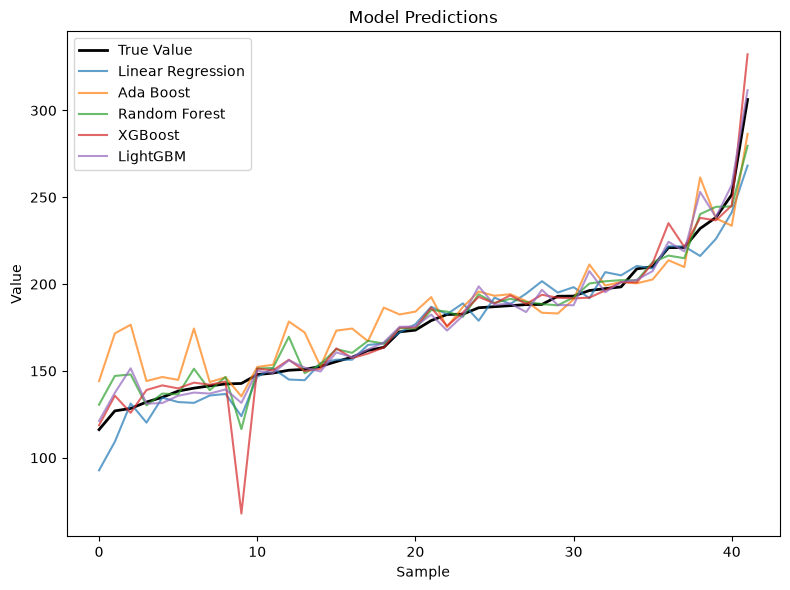

In [19]:
plot_df = pred_table.sort_values('true_val').reset_index(drop=True)

plt.figure(figsize=(8, 6))

plt.plot(plot_df.index, plot_df['true_val'], label='True Value', color='black', linewidth=2)
plt.plot(plot_df.index, plot_df['Linear Regression'], label='Linear Regression', alpha=0.7)
plt.plot(plot_df.index, plot_df['Ada Boost'], label='Ada Boost', alpha=0.7)
plt.plot(plot_df.index, plot_df['Random Forest'], label='Random Forest', alpha=0.7)
plt.plot(plot_df.index, plot_df['XGBoost'], label='XGBoost', alpha=0.7)
plt.plot(plot_df.index, plot_df['LightGBM'], label='LightGBM', alpha=0.7)

plt.xlabel('Sample')
plt.ylabel('Value')
plt.title('Model Predictions')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(lgbm_model, os.path.expanduser('~/code/drone/eda/models/duration_s_model.pkl'))

FileNotFoundError: [Errno 2] No such file or directory: '/home/dange/code/drone/eda/models/duration_s_model.pkl'

In [10]:
del df
gc.collect()
%whos

Variable                         Type         Data/Info
-------------------------------------------------------
AdaBoostRegressor                ABCMeta      <class 'sklearn.ensemble.<...>sting.AdaBoostRegressor'>
LGBMRegressor                    type         <class 'lightgbm.sklearn.LGBMRegressor'>
RandomForestRegressor            ABCMeta      <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
Ridge                            ABCMeta      <class 'sklearn.linear_model._ridge.Ridge'>
StandardScaler                   type         <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                                DataFrame    Shape: (209, 8)
XGBRegressor                     type         <class 'xgboost.sklearn.XGBRegressor'>
explained_variance_score         function     <function explained_varia<...>_score at 0x7fc2a9c2ca40>
gc                               module       <module 'gc' (built-in)>
mean_absolute_error              function     <function mean_absolute_error at 0x7fc2